# CareCompanion - Experiment Exploration
Analysis of A/B retrieval experiment results, confidence score distributions,
and safety layer performance across 14 logged queries.


In [4]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv('../.env')

DB_URL = (
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)
engine = create_engine(DB_URL)
plt.style.use('seaborn-v0_8-whitegrid')
print("Imports ready")
print(f"Connected to: {os.getenv('DB_NAME')}")

Imports ready
Connected to: carecompanion


## 1. A/B Experiment Results

In [5]:
exp_df = pd.read_sql("""
    SELECT strategy, query, relevance_score
    FROM experiment_runs
    WHERE experiment_name = 'dense_vs_hybrid'
    ORDER BY strategy, query
""", engine)

print(f"Total experiment runs: {len(exp_df)}")
print(f"Strategies: {exp_df['strategy'].unique()}")
exp_df.groupby('strategy')['relevance_score'].describe().round(4)

Total experiment runs: 40
Strategies: ['dense' 'hybrid']


,count,mean,std,min,25%,50%,75%,max
strategy,,,,,,,,
dense,20.0,0.7598,0.0891,0.6214,0.6946,0.7575,0.8504,0.919
hybrid,20.0,0.7788,0.0916,0.5379,0.7337,0.7995,0.8480,0.908


C:\Users\intel\AppData\Local\Temp\ipykernel_13476\2551856811.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([dense_scores, hybrid_scores], labels=['Dense', 'Hybrid'])


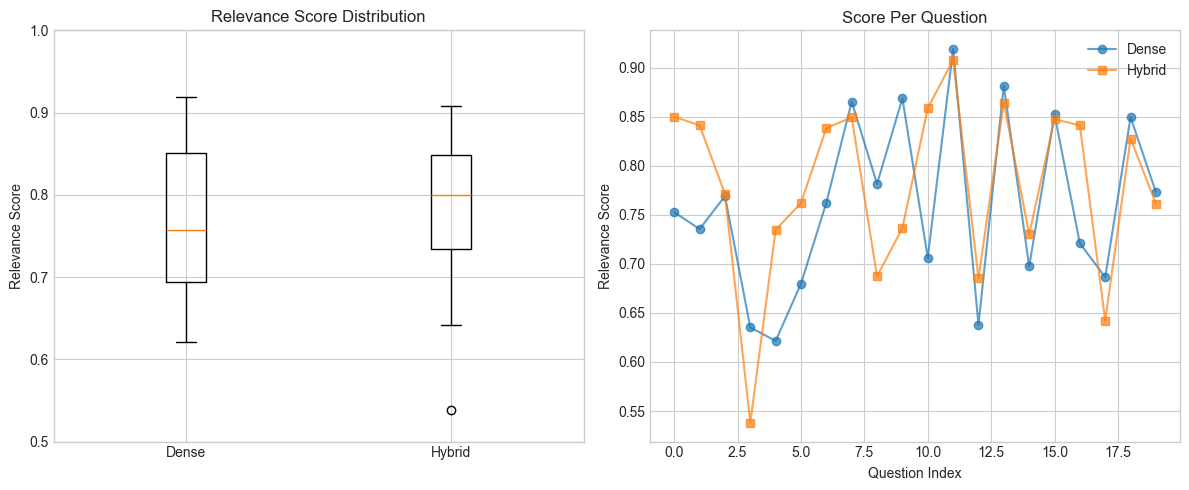

Dense mean: 0.7598
Hybrid mean: 0.7788
Difference: 0.0189


In [6]:
dense_scores = exp_df[exp_df['strategy'] == 'dense']['relevance_score'].values
hybrid_scores = exp_df[exp_df['strategy'] == 'hybrid']['relevance_score'].values

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box plot
axes[0].boxplot([dense_scores, hybrid_scores], labels=['Dense', 'Hybrid'])
axes[0].set_title('Relevance Score Distribution')
axes[0].set_ylabel('Relevance Score')
axes[0].set_ylim(0.5, 1.0)

# Score per question
x = np.arange(len(dense_scores))
axes[1].plot(x, dense_scores, 'o-', label='Dense', alpha=0.7)
axes[1].plot(x, hybrid_scores, 's-', label='Hybrid', alpha=0.7)
axes[1].set_title('Score Per Question')
axes[1].set_xlabel('Question Index')
axes[1].set_ylabel('Relevance Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('experiment_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Dense mean: {dense_scores.mean():.4f}")
print(f"Hybrid mean: {hybrid_scores.mean():.4f}")
print(f"Difference: {hybrid_scores.mean() - dense_scores.mean():.4f}")


## 2. Statistical Significance Testing

In [7]:
t_stat, p_value = stats.ttest_rel(hybrid_scores, dense_scores)
diff = hybrid_scores - dense_scores
ci = stats.t.interval(0.95, len(diff) - 1, loc=np.mean(diff), scale=stats.sem(diff))

print("=" * 45)
print("PAIRED T-TEST RESULTS")
print("=" * 45)
print(f"Dense mean score:      {dense_scores.mean():.4f}")
print(f"Hybrid mean score:     {hybrid_scores.mean():.4f}")
print(f"Mean difference:       {diff.mean():.4f}")
print(f"t-statistic:           {t_stat:.4f}")
print(f"p-value:               {p_value:.4f}")
print(f"95% CI:                [{ci[0]:.4f}, {ci[1]:.4f}]")
print()
if p_value < 0.05:
    print("Result: Statistically significant difference detected (p < 0.05)")
else:
    print("Result: No statistically significant difference (p >= 0.05)")
    print(f"Interpretation: {p_value*100:.1f}% probability this difference is random noise")


PAIRED T-TEST RESULTS
Dense mean score:      0.7598
Hybrid mean score:     0.7788
Mean difference:       0.0189
t-statistic:           1.0705
p-value:               0.2978
95% CI:                [-0.0181, 0.0560]

Result: No statistically significant difference (p >= 0.05)
Interpretation: 29.8% probability this difference is random noise


## 3. Query Confidence Score Distribution

In [9]:
logs_df = pd.read_sql("""
    SELECT query, confidence_score, safety_flagged,
           safety_category, retrieval_strategy, created_at
    FROM query_logs
    ORDER BY created_at
""", engine)

# Cast safety_flagged to boolean — PostgreSQL returns it as string via SQLAlchemy
logs_df['safety_flagged'] = logs_df['safety_flagged'].astype(bool)

print(f"Total queries logged: {len(logs_df)}")
print(f"Safety flagged: {logs_df['safety_flagged'].sum()}")
print(f"Normal queries: {(~logs_df['safety_flagged']).sum()}")
print()
logs_df[['confidence_score', 'safety_flagged']].describe().round(4)

Total queries logged: 14
Safety flagged: 6
Normal queries: 8



,confidence_score
count,14.0000
mean,0.3177
std,0.3404
min,0.0000
25%,0.0000
50%,0.2684
75%,0.5939
max,0.9872


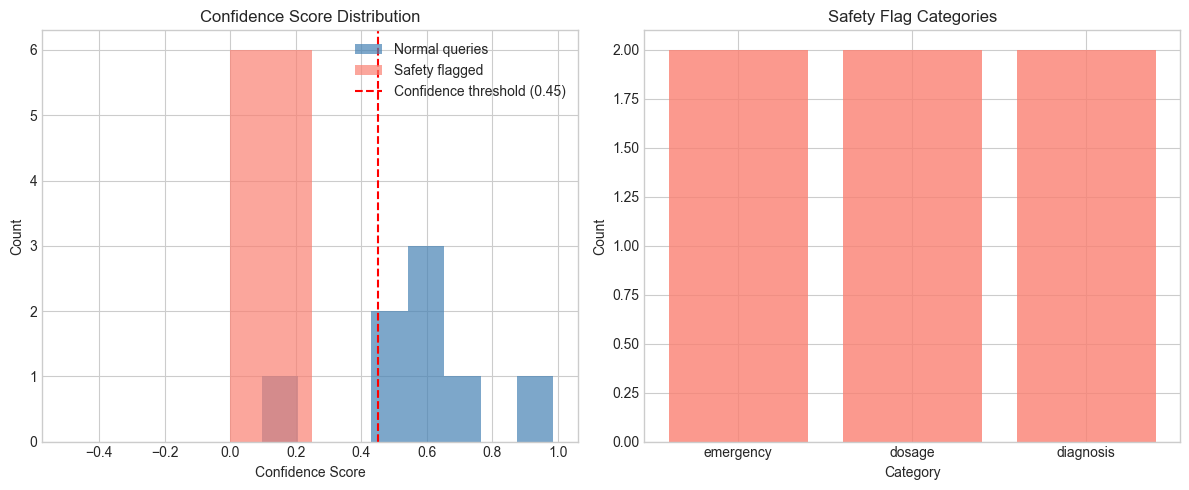

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confidence distribution
normal = logs_df[~logs_df['safety_flagged']]['confidence_score'].dropna()
flagged = logs_df[logs_df['safety_flagged']]['confidence_score'].fillna(0)

axes[0].hist(normal, bins=8, alpha=0.7, label='Normal queries', color='steelblue')
axes[0].hist(flagged, bins=4, alpha=0.7, label='Safety flagged', color='salmon')
axes[0].axvline(x=0.45, color='red', linestyle='--', label='Confidence threshold (0.45)')
axes[0].set_title('Confidence Score Distribution')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# Safety flags breakdown
categories = logs_df[logs_df['safety_flagged']]['safety_category'].value_counts()
if len(categories) > 0:
    axes[1].bar(categories.index, categories.values, color='salmon', alpha=0.8)
    axes[1].set_title('Safety Flag Categories')
    axes[1].set_xlabel('Category')
    axes[1].set_ylabel('Count')
else:
    axes[1].text(0.5, 0.5, 'No safety flags', ha='center', va='center')

plt.tight_layout()
plt.savefig('confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Knowledge Base Coverage

Total topics: 46
Total chunks: 1318
Avg chunks per topic: 28.7


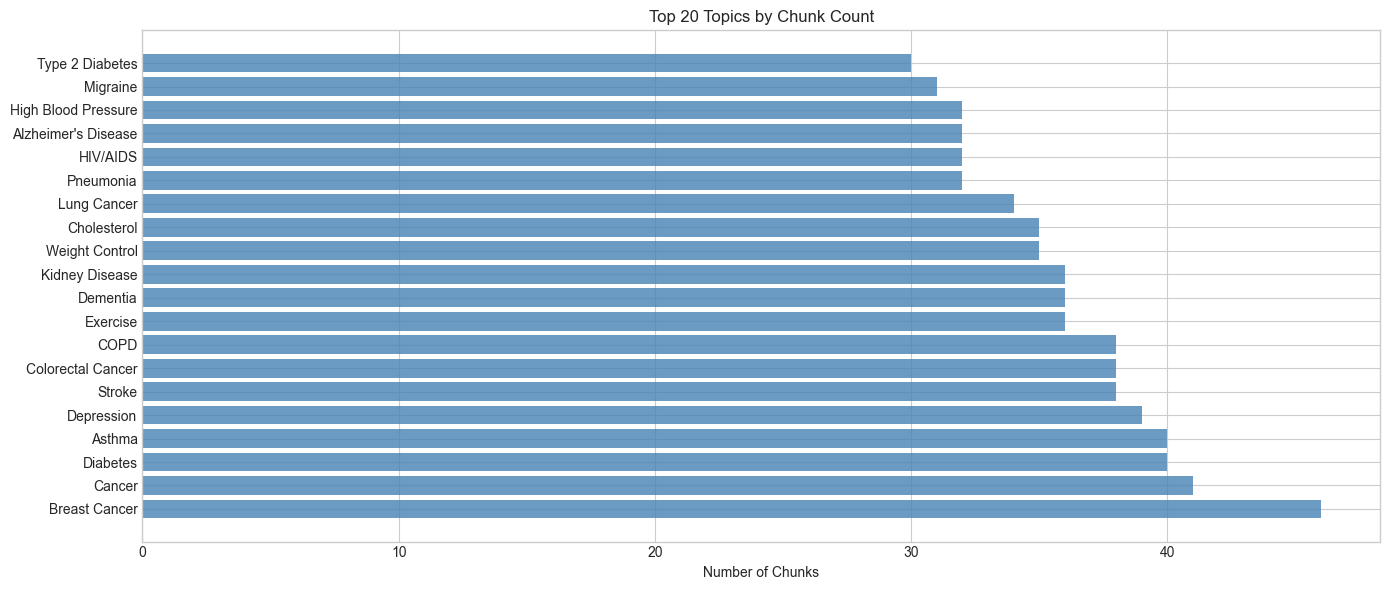

In [12]:
kb_df = pd.read_sql("""
    SELECT topic, COUNT(*) as chunks
    FROM knowledge_chunks
    GROUP BY topic
    ORDER BY chunks DESC
""", engine)

print(f"Total topics: {len(kb_df)}")
print(f"Total chunks: {kb_df['chunks'].sum()}")
print(f"Avg chunks per topic: {kb_df['chunks'].mean():.1f}")

plt.figure(figsize=(14, 6))
plt.barh(kb_df['topic'][:20], kb_df['chunks'][:20], color='steelblue', alpha=0.8)
plt.xlabel('Number of Chunks')
plt.title('Top 20 Topics by Chunk Count')
plt.tight_layout()
plt.savefig('knowledge_base_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Summary

| Metric | Value |
|--------|-------|
| Knowledge chunks | 1,318 |
| NIH topics | 46 |
| Dense mean relevance | 0.7598 |
| Hybrid mean relevance | 0.7788 |
| p-value | 0.298 (not significant) |
| Queries logged | 14 |
| Safety flags | 6 |
| Cache speedup | ~22x |

**Key finding:** Hybrid retrieval scores 2% higher on average but the difference
is not statistically significant (p=0.298). Both strategies perform well on
health-domain queries grounded in NIH MedlinePlus content.
